# Estadística inferencial, formulación de hipótesis e interpretación de resultados

## Clase de Analítica de Datos

Esta clase conecta la estadística inferencial con el ciclo real del análisis de datos: formular una pregunta, tomar una muestra, calcular evidencia, cuantificar incertidumbre, contrastar hipótesis e interpretar resultados con prudencia.

## Pregunta

> ¿Cómo puede un analista usar una muestra para tomar decisiones sobre una población o proceso, cuantificando la incertidumbre?

## Temas centrales

1. Inferencia estadística y variabilidad muestral.
2. Ley de los grandes números.
3. Teorema del límite central.
4. Intervalos de confianza.
5. Pruebas de hipótesis.
6. Bootstrap.
7. Interpretación de resultados.

## Bases reales utilizadas

1. **Diabetes dataset**: mediciones clínicas de pacientes y una variable de progresión de la enfermedad.
  442 pacientes, 10 variables basales estandarizadas y una variable respuesta de progresión de la enfermedad.
2. **Breast cancer Wisconsin dataset**: características de tumores usadas en clasificación diagnóstica.
   569 tumores, 30 variables calculadas a partir de imágenes digitalizadas y diagnóstico benigno/maligno.

Ambas bases están disponibles directamente en `sklearn.datasets`.

### Propósito de la clase

El objetivo no es aprender pruebas estadísticas de memoria. El objetivo es aprender a responder preguntas con datos reales:

- ¿Qué podemos estimar a partir de una muestra?
- ¿Qué tan incierta es una estimación?
- ¿Cuándo una diferencia observada puede atribuirse razonablemente al azar?
- ¿Cómo se interpreta un intervalo de confianza?
- ¿Qué significa y qué no significa un p-valor?
- ¿Cómo puede usarse bootstrap cuando no queremos depender demasiado de fórmulas paramétricas?

# 1. Preparación del entorno

In [4]:
%mamba install numpy pandas matplotlib seaborn scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.337 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.9      pyhd8ed1ab_0         conda-forge
+ idna                3.18       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.24.0     pyhcf101f3_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptool

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_diabetes, load_breast_cancer

np.random.seed(123)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Entorno preparado correctamente.")

Entorno preparado correctamente.


# 2. Cargar bases de Datos

Usaremos bases disponibles en `scikit-learn`.

## Diabetes dataset

La variable objetivo `disease_progression` mide la progresión de la enfermedad un año después de las mediciones clínicas. Las variables explicativas están estandarizadas.

- `age`: edad estandarizada;
- `bmi`: índice de masa corporal estandarizado;
- `bp`: presión arterial promedio estandarizada;
- `s1` a `s6`: mediciones sanguíneas estandarizadas;
- `disease_progression`: variable objetivo.

In [19]:
# por defecto load_diabetes() al ser una base de scikit-larn, devuelve los datos como arreglos de NumPy.
# Es por eso que lo convertimos a DataFrame. load_diabetes(as_frame=True): los devuelve como un DataFrame de pandas,

diab = load_diabetes(as_frame=True)
diabetes = diab.frame.copy().rename(columns={"target": "disease_progression"})
diabetes["bmi_group"] = np.where(
    diabetes["bmi"] >= diabetes["bmi"].median(),
    "BMI alto",
    "BMI bajo"
)

diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression,bmi_group
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0000,BMI alto
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0000,BMI bajo
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0000,BMI alto
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0000,BMI bajo
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0000,BMI bajo


In [20]:
diabetes.shape

(442, 12)

In [25]:
diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0000,-0.0000,0.0476,-0.1072,-0.0373,0.0054,0.0381,0.1107
sex,442.0000,0.0000,0.0476,-0.0446,-0.0446,-0.0446,0.0507,0.0507
bmi,442.0000,-0.0000,0.0476,-0.0903,-0.0342,-0.0073,0.0312,0.1706
bp,442.0000,-0.0000,0.0476,-0.1124,-0.0367,-0.0057,0.0356,0.1320
s1,442.0000,-0.0000,0.0476,-0.1268,-0.0342,-0.0043,0.0284,0.1539
s2,442.0000,0.0000,0.0476,-0.1156,-0.0304,-0.0038,0.0298,0.1988
s3,442.0000,-0.0000,0.0476,-0.1023,-0.0351,-0.0066,0.0293,0.1812
s4,442.0000,-0.0000,0.0476,-0.0764,-0.0395,-0.0026,0.0343,0.1852
s5,442.0000,0.0000,0.0476,-0.1261,-0.0332,-0.0019,0.0324,0.1336
s6,442.0000,0.0000,0.0476,-0.1378,-0.0332,-0.0011,0.0279,0.1356


In [22]:
diabetes.to_csv("diabetes.csv", index = False)

## Breast Cancer Wisconsin Diagnostic dataset

La variable `diagnosis` clasifica cada tumor como `benign` o `malignant`. Las variables numéricas describen características de núcleos celulares extraídas de imágenes.

In [84]:
bc = load_breast_cancer(as_frame=True)
breast = bc.frame.copy()
breast["diagnosis"] = breast["target"].map({0: "malignant", 1: "benign"})

display(breast[["mean radius", "mean texture", "mean area", "diagnosis"]].head())

,mean radius,mean texture,mean area,diagnosis
0,17.9900,10.3800,"1,001.0000",malignant
1,20.5700,17.7700,"1,326.0000",malignant
2,19.6900,21.2500,"1,203.0000",malignant
3,11.4200,20.3800,386.1000,malignant
4,20.2900,14.3400,"1,297.0000",malignant


In [85]:
print("Breast cancer:", breast.shape)
print("Diagnósticos:")
print(breast["diagnosis"].value_counts())

Breast cancer: (569, 32)
Diagnósticos:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


In [26]:
breast.to_csv("Breast_Cancer.csv", index = False)

# PARTE I. Fundamentos de inferencia estadística

# 3. ¿Qué es la inferencia estadística?

La **estadística descriptiva** resume los datos observados. La **inferencia estadística** busca ir más allá: usar una muestra para aprender sobre una población o sobre un proceso generador de datos.

En analítica de datos, la inferencia responde preguntas como:

- ¿Cuál es el valor plausible de una media poblacional?
- ¿Existe evidencia de diferencia entre dos grupos?
- ¿Una relación observada podría explicarse por variabilidad muestral?
- ¿Qué tan robusto es un hallazgo?

Formalmente, si una población tiene un parámetro desconocido $\theta$, y observamos una muestra aleatoria:

$$
X_1, X_2, \ldots, X_n,
$$

usamos un estadístico:

$$
\hat{\theta}=T(X_1,\ldots,X_n)
$$

para estimar $\theta$.

La inferencia siempre reconoce incertidumbre: diferentes muestras producen diferentes estimaciones.

## 3.1 Conceptos esenciales

| Concepto | Significado |
|---|---|
| Población | Conjunto completo de unidades de interés |
| Muestra | Subconjunto observado de la población |
| Parámetro | Cantidad poblacional desconocida, por ejemplo $\mu$ o $\sigma^2$ |
| Estadístico | Cantidad calculada con la muestra, por ejemplo $\bar X$ o $S^2$ |
| Estimador | Regla para aproximar un parámetro |
| Estimación | Valor numérico obtenido al aplicar el estimador |
| Error estándar | Desviación típica del estimador |
| Sesgo | Diferencia entre el valor esperado del estimador y el parámetro |

Un estimador es una variable aleatoria porque cambia de una muestra a otra.

Todo estimador es un estadístico, pero no todo estadístico es un estimador.

Si la población es:

$$
\mathcal{U}=\{X_1,\ldots,X_N\},
$$

una muestra de tamaño $n$ es:

$$
M=\{X_1,\ldots,X_n\}\subseteq \mathcal{U}.
$$

Si queremos estimar la media poblacional:

$$
\mu = \frac{1}{N}\sum_{i=1}^{N}x_i,
$$

usamos la media muestral:

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i.
$$


## Nota:
Si tomamos muchas muestras del mismo proceso, cada muestra produce una media diferente. Esa variabilidad se llama **variabilidad muestral**.

La inferencia estadística responde:

> Dado que mi resultado depende de la muestra, ¿qué tan confiable es mi conclusión?

# 4. De la pregunta al análisis inferencial

Un análisis inferencial debe iniciar con una pregunta clara.

Ejemplo con la base de diabetes:

> ¿Cuál es la progresión media de la enfermedad en pacientes similares a los observados?

Ejemplo con cáncer de mama:

> ¿El radio medio de los tumores malignos es mayor que el de los benignos?

Estructura:

1. Contexto.
2. Variable de interés.
3. Parámetro poblacional.
4. Estimador muestral.
5. Método inferencial.
6. Resultado numérico.
7. Interpretación.
8. Limitaciones.

# 5. Ley de los Grandes Números

## Propósito

La **Ley de los Grandes Números** justifica por qué una media muestral puede aproximar una media poblacional cuando el tamaño muestral aumenta.

Si $X_1,\ldots,X_n$ son variables aleatorias independientes e idénticamente distribuidas (muestra aleatoria) con media finita $\mu$, entonces:

$$
\bar X_n = \frac{1}{n}\sum_{i=1}^{n}X_i
$$

converge a $\mu$ cuando $n\to\infty$:

$$
\bar X_n \xrightarrow{P} \mu.
$$

Esto no significa que muestras pequeñas sean exactas. Significa que, bajo condiciones adecuadas, el promedio se estabiliza con muestras grandes.

## 5.1 Simulación de la ley de los grandes números

Simularemos una población asimétrica a partr de números aleatorios provenientes de una distribución binomial. 

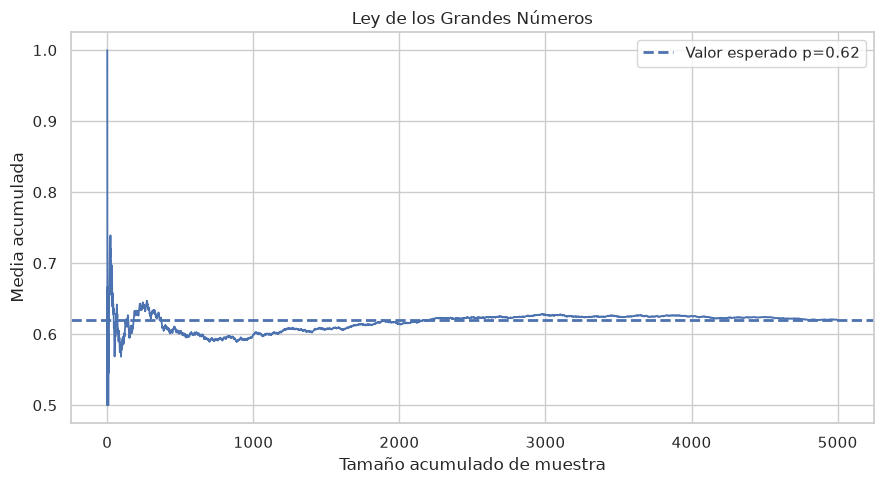

In [68]:
p = 0.62
nmax = 5000
x = np.random.binomial(1, p, nmax)
media_acumulada = np.cumsum(x) / np.arange(1, nmax + 1)

plt.figure(figsize=(9, 5))
plt.plot(media_acumulada, linewidth=1.3)
plt.axhline(p, linestyle="--", linewidth=2, label="Valor esperado p=0.62")
plt.title("Ley de los Grandes Números")
plt.xlabel("Tamaño acumulado de muestra")
plt.ylabel("Media acumulada")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretación

La media acumulada fluctúa al inicio porque hay poca información. A medida que aumenta el tamaño de muestra, se estabiliza alrededor del valor esperado.

**Esta idea advierte que conclusiones basadas en pocos datos pueden ser muy inestables**.

# 6. Distribución muestral

Una distribución muestral describe cómo varía un estadístico de muestra en muestra.

Si repitiéramos muchas veces el proceso de muestreo y calculáramos $\bar X$ en cada muestra, obtendríamos una distribución de medias muestrales.

Para la media:

$$
E(\bar X)=\mu,
$$

Varianza de la media
$$
Var(\bar X)=\frac{\sigma^2}{n},
$$

Error estandar e la media
$$
SE(\bar X)=\frac{\sigma}{\sqrt n}.
$$
Si $\sigma$ es desconocida, se usa:

$$
SE(\bar{X})\approx\frac{s}{\sqrt{n}}.
$$

El error estándar disminuye con $\sqrt n$, no con $n$. Por eso duplicar la precisión requiere aumentar mucho el tamaño muestral.

# 7. Teorema del Límite Central

## Propósito

El **Teorema del Límite Central (TLC)** permite aproximar la distribución de la media muestral por una distribución normal, incluso cuando la población original no es normal, siempre que el tamaño de muestra sea suficientemente grande y se cumplan condiciones apropiadas.

Si $X_1,\ldots,X_n$ son i.i.d. con media $\mu$ y varianza finita $\sigma^2$, entonces:

$$
\frac{\bar X-\mu}{\sigma/\sqrt n}
\xrightarrow{d}
N(0,1).
$$

En consecuencia, para $n$ grande:

$$
\bar X \approx N\left(\mu,\frac{\sigma^2}{n}\right).
$$

## 7.1 Simulación del TLC

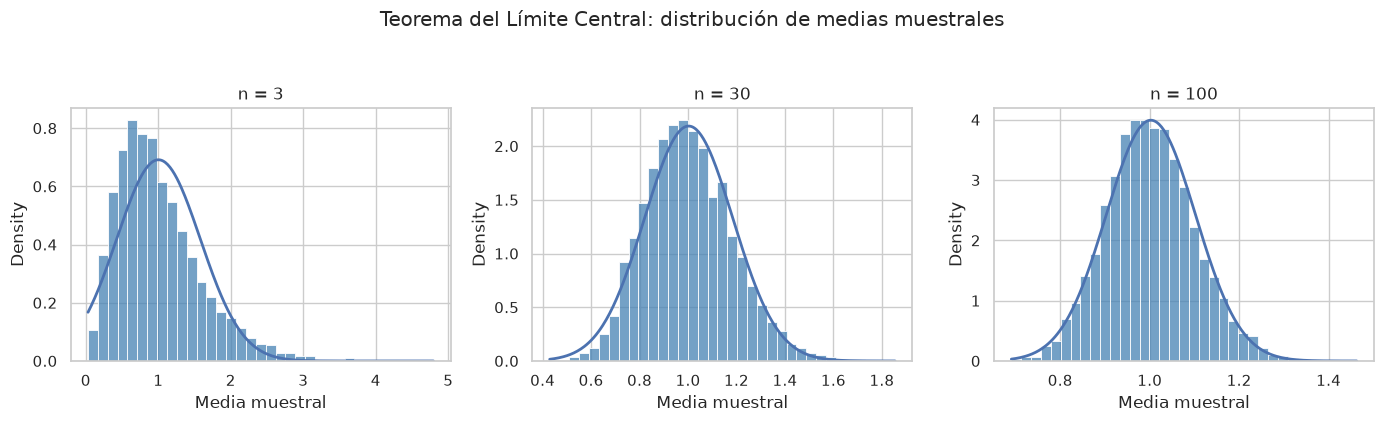

In [69]:
poblacion = np.random.exponential(scale=1.0, size=200000)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, n in zip(axes, [3, 30, 100]):
    medias = np.mean(
        np.random.choice(poblacion, size=(5000, n), replace=True),
        axis=1
    )
    sns.histplot(medias, bins=35, stat="density", ax=ax, color="steelblue")

    mu = poblacion.mean()
    se = poblacion.std(ddof=0) / np.sqrt(n)
    grid = np.linspace(medias.min(), medias.max(), 300)
    ax.plot(grid, stats.norm.pdf(grid, mu, se), linewidth=2)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Media muestral")

plt.suptitle("Teorema del Límite Central: distribución de medias muestrales", y=1.05)
plt.tight_layout()
plt.show()

## Interpretación

La población simulada es asimétrica. Sin embargo, al aumentar $n$, la distribución de las medias se vuelve más simétrica y cercana a una normal.

El TLC es la razón por la que muchos intervalos de confianza y pruebas estadísticas usan aproximaciones normales.

# 8. Estimación puntual

Una estimación puntual resume un parámetro con un solo número.

Ejemplo: estimar la progresión media de enfermedad en la base de diabetes.

El estimador natural de la media poblacional $\mu$ es:

$$
\bar X = \frac{1}{n}\sum_{i=1}^{n}X_i.
$$

El estimador de la proporción poblacional $p$ es:

$$
\hat p = \frac{X}{n},
$$

donde $X$ es el número de casos con la característica de interés.

In [71]:
x = diabetes["disease_progression"]
media_progresion = x.mean()
mediana_progresion = x.median()
se_media = x.std(ddof=1) / np.sqrt(len(x))

print("Tamaño muestral:", len(x))
print("Media muestral:", media_progresion)
print("Mediana muestral:", mediana_progresion)
print("Error estándar de la media:", se_media)
print("Máximo:", x.max())
print("Máximo:", x.min())

Tamaño muestral: 442
Media muestral: 152.13348416289594
Mediana muestral: 140.5
Error estándar de la media: 3.6669402794976396
Máximo: 346.0
Máximo: 25.0


# PARTE II. Intervalos de confianza

# 9. Intervalos de confianza

## Propósito

Un intervalo de confianza busca cuantificar la incertidumbre de una estimación.

No basta decir:

> La media estimada es 152.13.

Es mejor decir:

> La media estimada es 152.13 y un rango plausible para la media poblacional es aproximadamente de 150 a 159.

## Idea general

Un intervalo de confianza tiene forma:

$$
\text{estimación} \pm \text{margen de error}.
$$

Para una media, con una población grande y en la que se conoce su varianza se puede usar la distribución normal, el intervalo es:

$$
\bar X \pm z_{1- \alpha/2}\frac{\sigma}{\sqrt n}.
$$

Es decir:

$$
IC_{1-\alpha}(\mu)
=
\left(
\bar{X}-z_{1-\alpha/2}\frac{\sigma}{\sqrt n},
\bar{X}+z_{1-\alpha/2}\frac{\sigma}{\sqrt n}
\right).
$$

Donde:

- $\bar X$ es la media muestral;
- $S$ es la desviación estándar muestral;
- $n$ es el tamaño muestral;
- $z_{1-\alpha/2}$ es un cuantíl o valor crítico de la distribución normal.
- $1-\alpha$: nivel de confianza.

<center>
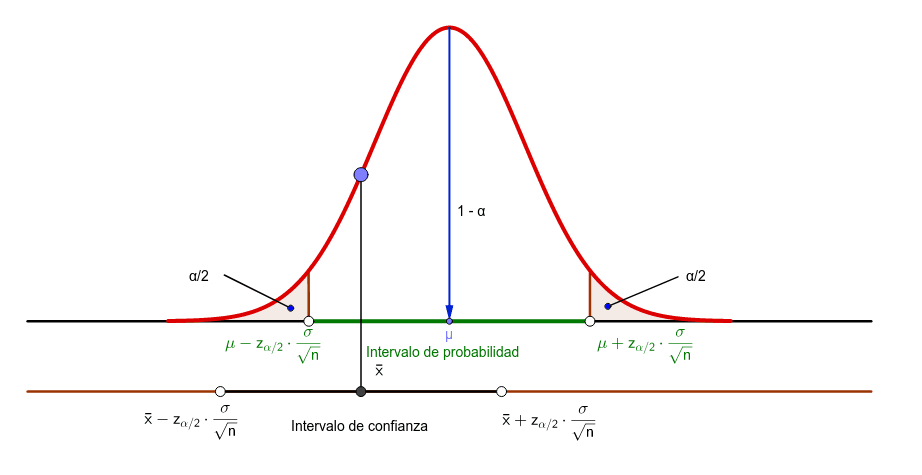
</center>

Para una media, si la desviación poblacional es desconocida se usa la distribución t, el intervalo es:

$$
\bar X \pm t_{1-\alpha/2,n-1}\frac{S}{\sqrt n}.
$$

Es decir:

$$
IC_{1-\alpha}(\mu)
=
\left(
\bar{X}-t_{\alpha/2,n-1}\frac{S}{\sqrt{n}},
\bar{X}+t_{\alpha/2,n-1}\frac{S}{\sqrt{n}}
\right).
$$

Donde $t_{1-\alpha/2,n-1}$ es un cuantíl o valor crítico de la distribución t de Student.

## 9.1 Intervalo de confianza para la progresión promedio (Diabetes dataset)

Pregunta:

> ¿Cuál es un rango plausible para la progresión promedio de la enfermedad en la población de pacientes similares?

### IC al 95% usando la distribución t-student

In [72]:
alpha = 0.05
n = len(x)
media = x.mean()
s = x.std(ddof=1)
se = s / np.sqrt(n)
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)

li = media - t_crit * se
ls = media + t_crit * se

print(f"Tamaño muestra: {n:.3f}")
print(f"Media: {media:.3f}")
print(f"Desviación estandar: {s:.3f}")
print(f"Error estándar: {se:.3f}")
print(f"t crítico: {t_crit:.3f}")
print(f"IC 95%: [{li:.3f}, {ls:.3f}]")

Tamaño muestra: 442.000
Media: 152.133
Desviación estandar: 77.093
Error estándar: 3.667
t crítico: 1.965
IC 95%: [144.927, 159.340]


### IC al 95% usando la distribución Normal

In [83]:
alpha = 0.05

n = len(x)
media = np.mean(x)
s = np.std(x, ddof=1)
se = s / np.sqrt(n)

# Valor crítico Z
z_crit = stats.norm.ppf(1 - alpha/2)

li = media - z_crit * se
ls = media + z_crit * se

print(f"Tamaño muestra: {n:.3f}")
print(f"Media: {media:.3f}")
print(f"Desviación estándar: {s:.3f}")
print(f"Error estándar: {se:.3f}")
print(f"Valor crítico Z: {z_crit:.3f}")
print(f"IC 95%: [{li:.3f}, {ls:.3f}]")

Tamaño muestra: 442.000
Media: 152.133
Desviación estándar: 77.093
Error estándar: 3.667
Valor crítico Z: 1.960
IC 95%: [144.946, 159.321]


## Interpretación 

Un intervalo de confianza del 95% no significa que exista 95% de probabilidad de que este intervalo particular contenga a $\mu$.

La interpretación frecuentista es:

> Si repitiéramos el muestreo muchas veces y construyéramos intervalos con el mismo procedimiento, aproximadamente el 95% de esos intervalos contendría el verdadero parámetro poblacional.

En la práctica decimos:

> Con el procedimiento usado, el intervalo ofrece un rango plausible para la media poblacional.

<center>
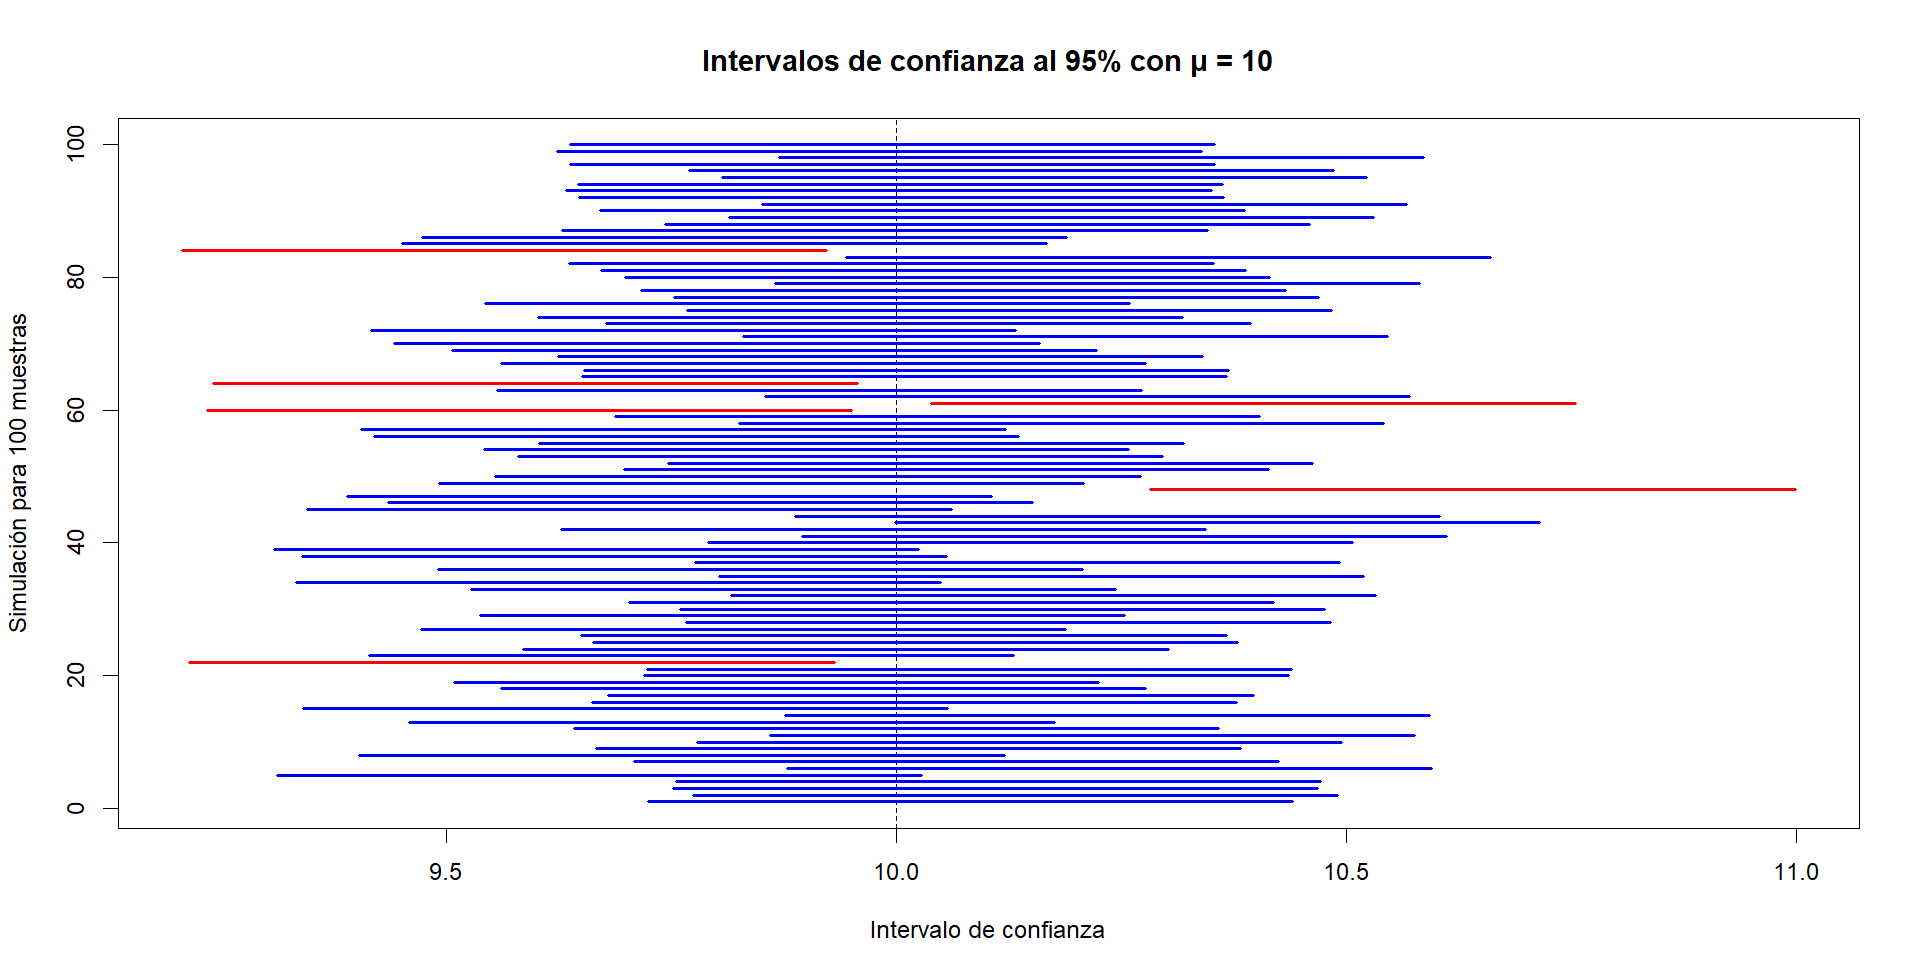
</center>

# 10. Intervalo de confianza para una proporción

Si $X$ es el número de éxitos en $n$ observaciones, la proporción muestral es:

$$
\hat p=\frac{X}{n}.
$$

Para muestras grandes, por el TLC:

$$
\hat p \approx N\left(p,\frac{p(1-p)}{n}\right).
$$

Un intervalo aproximado es:

$$
\hat p \pm z_{1-\alpha/2}\sqrt{\frac{\hat p(1-\hat p)}{n}}.
$$

## 10.1 Intervalo de confianza para la proporción de personas con tumor maligno (Breast Cancer Wisconsin Diagnostic dataset)

In [89]:
es_maligno = breast["diagnosis"].eq("malignant")
n = len(breast)
x_mal = es_maligno.sum()
p_hat = x_mal / n
z_crit = stats.norm.ppf(0.975)
se_p = np.sqrt(p_hat * (1 - p_hat) / n)
ci_p = (p_hat - z_crit * se_p, p_hat + z_crit * se_p)

print("n:", n)
print("Tumores malignos:", x_mal)
print(f"Proporción observada: {p_hat:.4f}")
print(f"IC 95% aproximado: [{ci_p[0]:.4f}, {ci_p[1]:.4f}]")

n: 569
Tumores malignos: 212
Proporción observada: 0.3726
IC 95% aproximado: [0.3329, 0.4123]


# 11. Intervalo de confianza para diferencia de medias

Supongamos que queremos comparar el `mean radius` (radio promedio de los núcleos celulares observados en una muestra) de tumores malignos y benignos.

El parámetro de interés es:

$$
\Delta = \mu_M - \mu_B.
$$

Su estimador es:

$$
\widehat{\Delta}=\bar X_M-\bar X_B.
$$

Si no asumimos varianzas iguales, usamos el error estándar de Welch:

$$
SE(\widehat{\Delta})=
\sqrt{\frac{s_M^2}{n_M}+\frac{s_B^2}{n_B}}.
$$

## 11.1 Intervalo de confianza para la diferencia de medias de `mean radius` de tumores malignos y benignos (Breast Cancer Wisconsin Diagnostic dataset)

In [90]:
mal = breast.loc[breast["diagnosis"] == "malignant", "mean radius"]
ben = breast.loc[breast["diagnosis"] == "benign", "mean radius"]

diff = mal.mean() - ben.mean()
se_diff = np.sqrt(mal.var(ddof=1)/len(mal) + ben.var(ddof=1)/len(ben))

# Grados de libertad de Welch
num = (mal.var(ddof=1)/len(mal) + ben.var(ddof=1)/len(ben))**2
den = ((mal.var(ddof=1)/len(mal))**2/(len(mal)-1) +
       (ben.var(ddof=1)/len(ben))**2/(len(ben)-1))
df_welch = num / den

tcrit = stats.t.ppf(0.975, df=df_welch)
ci_diff = (diff - tcrit * se_diff, diff + tcrit * se_diff)

print(f"Media malignant: {mal.mean():.3f}")
print(f"Media benign: {ben.mean():.3f}")
print(f"Diferencia observada: {diff:.3f}")
print(f"IC 95% para diferencia: [{ci_diff[0]:.3f}, {ci_diff[1]:.3f}]")

Media malignant: 17.463
Media benign: 12.147
Diferencia observada: 5.316
IC 95% para diferencia: [4.845, 5.787]


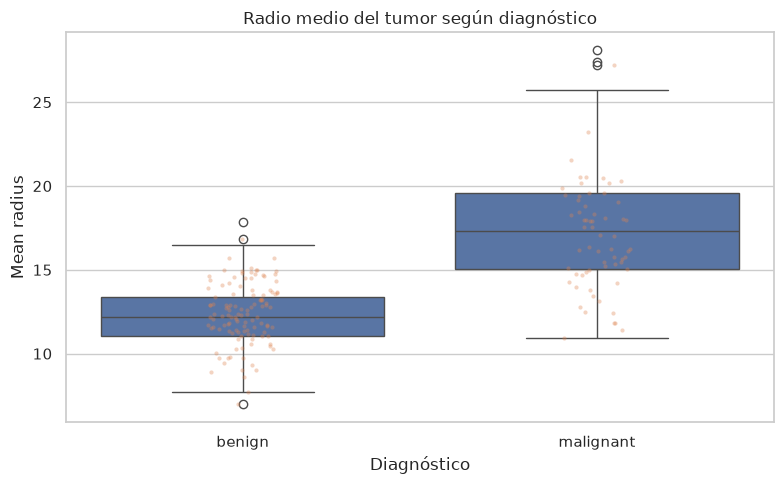

In [92]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=breast, x="diagnosis", y="mean radius", order=["benign", "malignant"])
sns.stripplot(
    data=breast.sample(180, random_state=1),
    x="diagnosis",
    y="mean radius",
    order=["benign", "malignant"],
    alpha=0.35,
    size=3
)
plt.title("Radio medio del tumor según diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("Mean radius")
plt.tight_layout()
plt.show()

# Resumen: Intervalos de Confianza

Los **intervalos de confianza (IC)** permiten estimar un **parámetro poblacional** a partir de una muestra, proporcionando un rango de valores plausibles para dicho parámetro con un nivel de confianza determinado (por ejemplo, 95%).

---

## Tabla resumen

| Parámetro a estimar | Estadístico | Intervalo de confianza | Distribución utilizada | ¿Cuándo se usa? |
| -------------------------------------------- | ----------------------- | ------------------------------------------------------------------------------------------------------------------------------------ | --------------------------- | -------------------------------------------------------------------------------------------------- |
| **Media poblacional** ($\mu$) | $\bar{x}$ | $\displaystyle \bar{x}\pm z_{\alpha/2}\frac{\sigma}{\sqrt{n}}$ | **Normal (Z)** | Cuando la desviación estándar poblacional ($\sigma$) es conocida o $n\ge 30$. |
| **Media poblacional** ($\mu$) | $\bar{x}$ | $\displaystyle \bar{x}\pm t_{\alpha/2,n-1}\frac{s}{\sqrt{n}}$ | **t de Student** | Cuando $\sigma$ es desconocida y la población es aproximadamente normal (especialmente si $n<30$). |
| **Proporción poblacional** ($p$) | $\hat p$ | $\displaystyle \hat p\pm z_{\alpha/2}\sqrt{\frac{\hat p(1-\hat p)}{n}}$ | **Normal (Z)** | Cuando $n\hat p\ge5$ y $n(1-\hat p)\ge5$. |
| **Varianza poblacional** ($\sigma^2$) | $s^2$ | $\displaystyle \left(\frac{(n-1)s^2}{\chi^2_{\alpha/2}},\frac{(n-1)s^2}{\chi^2_{1-\alpha/2}}\right)$ | **Chi-cuadrado ($\chi^2$)** | Cuando la población sigue una distribución normal. |
| **Desviación estándar** ($\sigma$) | $s$ | Raíz cuadrada del IC para la varianza | **Chi-cuadrado ($\chi^2$)** | Cuando la población es normal. |
| **Diferencia de medias** ($\mu_1-\mu_2$) | $\bar{x}_1-\bar{x}_2$ | Depende del caso (Z o t) | **Normal o t de Student** | Dos muestras independientes o pareadas. |
| **Diferencia de proporciones** ($p_1-p_2$) | $\hat p_1-\hat p_2$ | $\displaystyle (\hat p_1-\hat p_2)\pm z_{\alpha/2}\sqrt{\frac{\hat p_1(1-\hat p_1)}{n_1}+\frac{\hat p_2(1-\hat p_2)}{n_2}}$ | **Normal (Z)** | Comparación entre dos proporciones. |

---

## ¿Qué distribución se utiliza?

| Situación | Distribución |
|-----------|--------------|
| Media con $\sigma$ conocida | **Normal (Z)** |
| Media con $\sigma$ desconocida | **t de Student** |
| Proporciones | **Normal (Z)** |
| Varianza o desviación estándar | **Chi-cuadrado ($\chi^2$)** |
| Diferencia de medias | **Normal o t** |
| Diferencia de proporciones | **Normal (Z)** |

---

## Regla práctica

- **Z** → Media con \(\sigma\) conocida o muestras grandes; también para proporciones.
- **t de Student** → Media con \(\sigma\) desconocida.
- **Chi-cuadrado** → Varianza y desviación estándar.
- **F de Fisher** → Comparación de dos varianzas (menos frecuente en cursos introductorios).



# PARTE III. Pruebas de hipótesis

# 12. Formulación de hipótesis

Una prueba de hipótesis contrasta una afirmación sobre un parámetro poblacional.

Los componentes son:

1. **Hipótesis nula** $H_0$: afirmación inicial o de referencia.
2. **Hipótesis alternativa** $H_1$: afirmación que se busca evaluar.
3. **Estadístico de prueba**: cantidad calculada desde los datos.
4. **Distribución bajo $H_0$**: comportamiento esperado si $H_0$ fuera cierta.
5. **p-valor**: evidencia contra $H_0$.
6. **Nivel de significancia** $\alpha$: umbral de decisión.

## Propósito

Una prueba de hipótesis evalúa si los datos observados son compatibles con una afirmación inicial llamada hipótesis nula.

La lógica general es:

1. Se plantea una hipótesis nula $H_0$.
2. Se plantea una hipótesis alternativa $H_1$.
3. Se calcula un estadístico de prueba.
4. Se calcula un p-valor.
5. Se decide si la evidencia contra $H_0$ es suficiente.
6. Se interpreta en contexto.

Una prueba no demuestra que una hipótesis sea verdadera. Evalúa la compatibilidad de los datos con $H_0$.

## 12.1 Hipótesis nula y alternativa

La hipótesis nula suele representar una situación de referencia:

$$
H_0: \theta=\theta_0.
$$

La hipótesis alternativa representa lo que se quiere evaluar:

$$
H_1: \theta\neq\theta_0,
$$

$$
H_1: \theta>\theta_0,
$$

$$
H_1: \theta<\theta_0.
$$

La alternativa puede ser bilateral o unilateral.

<center>
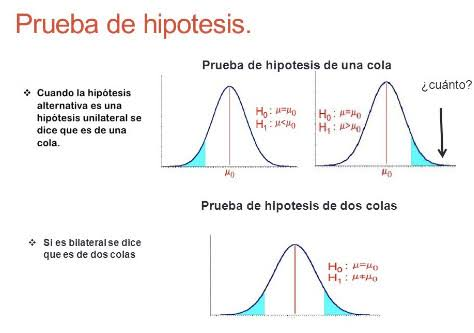
</center>

## 12.2 Estadístico de prueba

Un estadístico de prueba mide qué tan lejos está la estimación observada de lo esperado bajo $H_0$.

Una forma común es:

$$
\text{estadístico}
=
\frac{
\text{estimación observada}-\text{valor bajo }H_0
}{
\text{error estándar bajo }H_0
}.
$$

Valores extremos indican menor compatibilidad con $H_0$.

### Estadístico t para una media

Cuando $\sigma$ es desconocida, se usa:

$$
t=
\frac{\bar{x}-\mu_0}{s/\sqrt{n}}.
$$

Bajo $H_0$, si los supuestos son razonables:

$$
t\sim t_{n-1}.
$$

## 12.3 P-valor

El p-valor es la probabilidad, suponiendo que $H_0$ es verdadera, de observar un resultado tan extremo o más extremo que el observado:

$$
p\text{-valor}
=
P(\text{resultado tan extremo como el observado}\mid H_0).
$$

Para una prueba bilateral:

$$
p\text{-valor}
=
P\left(|T|\geq |t_{obs}|\mid H_0\right).
$$


No es la probabilidad de que $H_0$ sea verdadera.

No es la probabilidad de que el resultado se deba al azar.

Es una medida de incompatibilidad entre datos y $H_0$.

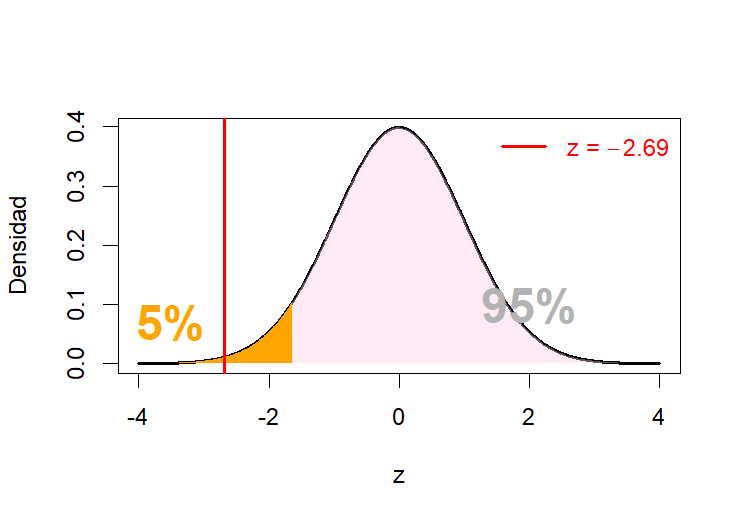

## 12.4 Nivel de significancia y regla de decisión

El nivel de significancia $\alpha$ es el umbral máximo tolerado para el error tipo I:

$$
\alpha=P(\text{rechazar }H_0\mid H_0\text{ verdadera}).
$$

Usualmente se usa:

$$
\alpha=0.05.
$$

Regla de decisión:

$$
\text{si p-valor}<\alpha,
\text{ se rechaza }H_0.
$$

$$
\text{si p-valor}\geq\alpha,
\text{ no se rechaza }H_0.
$$

### El valor de significancia se determina antes de iniciar la prueba.

Importante:

- No rechazar $H_0$ no significa demostrar que $H_0$ sea verdadera.
- Un p-valor pequeño no mide el tamaño del efecto.
- La significancia estadística no implica relevancia práctica.

## 12.5 Tipos de error

| Decisión | $H_0$ verdadera | $H_0$ falsa |
|---|---|---|
| No rechazar $H_0$ | Decisión correcta | Error tipo II |
| Rechazar $H_0$ | Error tipo I | Decisión correcta |

Error tipo I:

$$
\alpha=P(\text{rechazar }H_0\mid H_0 \text{ verdadera}).
$$

Error tipo II:

$$
\beta=P(\text{no rechazar }H_0\mid H_0 \text{ falsa}).
$$

Potencia:

$$
1-\beta.
$$

# 13. Prueba de hipótesis para la progresión promedio

Pregunta:

> ¿La progresión media de enfermedad en la base de diabetes `disease_progression` es diferente de 150?

Hipótesis:

$$
H_0: \mu=150
$$

$$
H_1: \mu\neq 150
$$

Estadístico t:

$$
t=
\frac{\bar X-\mu_0}{s/\sqrt n}.
$$

In [94]:
mu0 = 150
alpha = 0.05
x = diabetes["disease_progression"]
n = len(x)
media = x.mean()
s = x.std(ddof=1)
se = s / np.sqrt(n)
t_obs = (media - mu0) / se
p_valor = 2 * (1 - stats.t.cdf(abs(t_obs), df=n-1))

print(f"Nivel de significancia (α): {alpha:.2f}")
print(f"Media observada: {media:.3f}")
print(f"Estadístico t observado: {t_obs:.3f}")
print(f"p-valor: {p_valor:.4f}")

# Decisión
if p_valor < alpha:
    print("\nDecisión: Se rechaza la hipótesis nula (H₀).")
    print(f"Existe evidencia estadísticamente significativa para afirmar que la media poblacional es diferente de {mu0}.")
else:
    print("\nDecisión: No se rechaza la hipótesis nula (H₀).")
    print(f"No existe evidencia estadísticamente significativa para afirmar que la media poblacional es diferente de {mu0}.")

Nivel de significancia (α): 0.05
Media observada: 152.133
Estadístico t observado: 0.582
p-valor: 0.5610

Decisión: No se rechaza la hipótesis nula (H₀).
No existe evidencia estadísticamente significativa para afirmar que la media poblacional es diferente de 150.


## Interpretación

Si el p-valor es pequeño, la media observada sería poco compatible con una población cuya media fuera 150.

Si el p-valor no es pequeño, no significa que $\mu=150$ sea verdadero. Significa que la muestra no aporta evidencia suficiente para rechazar esa referencia al nivel elegido.

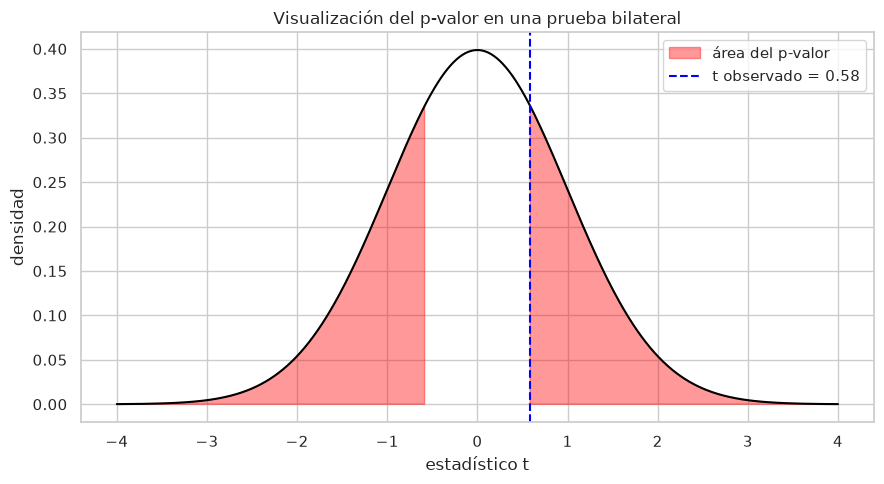

t observado: 0.581815901072766
p-valor: 0.5609879799995241


In [95]:
n = len(x)
xbar = x.mean()
s = x.std(ddof=1)
t_obs = (xbar - mu0) / (s / np.sqrt(n))
grados = n - 1
pvalor = 2 * (1 - stats.t.cdf(abs(t_obs), df=grados))

xx = np.linspace(-4, 4, 500)
yy = stats.t.pdf(xx, df=grados)

plt.figure(figsize=(9, 5))
plt.plot(xx, yy, color="black")
plt.fill_between(
    xx,
    0,
    yy,
    where=(xx <= -abs(t_obs)) | (xx >= abs(t_obs)),
    alpha=0.4,
    color="red",
    label="área del p-valor"
)
plt.axvline(t_obs, color="blue", linestyle="--", label=f"t observado = {t_obs:.2f}")
plt.title("Visualización del p-valor en una prueba bilateral")
plt.xlabel("estadístico t")
plt.ylabel("densidad")
plt.legend()
plt.tight_layout()
plt.show()

print("t observado:", t_obs)
print("p-valor:", pvalor)

# 14. Prueba para dos medias independientes

## Pregunta

> ¿El radio medio de los núcleos celulares en los tumores malignos es mayor que en los tumores benignos?

En esta comparación se tienen dos grupos independientes:

- **Grupo 1:** tumores malignos.
- **Grupo 2:** tumores benignos.
- **Variable analizada:** `mean radius`, que representa el radio promedio de los núcleos celulares observados en cada muestra.

Sean:

$$
\mu_M = \text{radio medio poblacional de los tumores malignos},
$$

$$
\mu_B = \text{radio medio poblacional de los tumores benignos}.
$$

Como se desea determinar si el radio medio de los tumores malignos es **mayor**, se formula una prueba unilateral a la derecha:

$$
H_0:\mu_M-\mu_B\leq 0,
$$

$$
H_1:\mu_M-\mu_B>0.
$$

La hipótesis nula afirma que el radio medio de los tumores malignos no es mayor que el de los benignos. La hipótesis alternativa plantea que sí es mayor.

## Prueba t de Welch

Se utilizará la **prueba t de Welch para dos muestras independientes**, porque permite comparar las medias de dos grupos sin suponer que sus varianzas poblacionales son iguales.

El estadístico de prueba es:

$$
t=
\frac{\bar{x}_M-\bar{x}_B}
{\sqrt{\dfrac{s_M^2}{n_M}+\dfrac{s_B^2}{n_B}}},
$$

donde:

- $\bar{x}_M$ y $\bar{x}_B$ son las medias muestrales;
- $s_M^2$ y $s_B^2$ son las varianzas muestrales;
- $n_M$ y $n_B$ son los tamaños de los grupos.

Se utilizará un nivel de significancia de:

$$
\alpha=0.05.
$$

La regla de decisión es:

- si el p-valor es menor que $\alpha$, se rechaza $H_0$;
- si el p-valor es mayor o igual que $\alpha$, no se rechaza $H_0$.

In [102]:
# Nivel de significancia
alpha = 0.05

mal = np.asarray(mal, dtype=float)
ben = np.asarray(ben, dtype=float)

mal = mal[~np.isnan(mal)]
ben = ben[~np.isnan(ben)]

# Estadísticos descriptivos
n_mal = len(mal)
n_ben = len(ben)

media_mal = mal.mean()
media_ben = ben.mean()

desv_mal = mal.std(ddof=1)
desv_ben = ben.std(ddof=1)

diferencia_medias = media_mal - media_ben

# Prueba t de Welch unilateral:
# H1: media de malignos > media de benignos
resultado_t = stats.ttest_ind(
    mal,
    ben,
    equal_var=False,
    alternative="greater"
)

t_observado = resultado_t.statistic
p_valor = resultado_t.pvalue

# Presentación de resultados
print("PRUEBA T DE WELCH PARA DOS MEDIAS INDEPENDIENTES")
print("-" * 58)

print("\nEstadísticos descriptivos:")
print(f"Tumores malignos: n = {n_mal}")
print(f"  Media = {media_mal:.3f}")
print(f"  Desviación estándar = {desv_mal:.3f}")

print(f"\nTumores benignos: n = {n_ben}")
print(f"  Media = {media_ben:.3f}")
print(f"  Desviación estándar = {desv_ben:.3f}")

print("\nComparación:")
print(f"Diferencia de medias (malignos - benignos): {diferencia_medias:.3f}")

print("\nResultados de la prueba:")
print(f"Nivel de significancia: {alpha}")
print(f"Estadístico t: {t_observado:.3f}")
print(f"p-valor unilateral: {p_valor:.6f}")

# Decisión e interpretación
print("\nDecisión estadística:")

if p_valor < alpha:
    print("Se rechaza la hipótesis nula H0.")
    print(
        "Existe evidencia estadísticamente significativa para concluir "
        "que el radio medio de los núcleos celulares en los tumores "
        "malignos es mayor que en los tumores benignos."
    )
else:
    print("No se rechaza la hipótesis nula H0.")
    print(
        "La evidencia muestral no es suficiente para concluir que el "
        "radio medio de los núcleos celulares en los tumores malignos "
        "sea mayor que en los tumores benignos."
    )

PRUEBA T DE WELCH PARA DOS MEDIAS INDEPENDIENTES
----------------------------------------------------------

Estadísticos descriptivos:
Tumores malignos: n = 212
  Media = 17.463
  Desviación estándar = 3.204

Tumores benignos: n = 357
  Media = 12.147
  Desviación estándar = 1.781

Comparación:
Diferencia de medias (malignos - benignos): 5.316

Resultados de la prueba:
Nivel de significancia: 0.05
Estadístico t: 22.209
p-valor unilateral: 0.000000

Decisión estadística:
Se rechaza la hipótesis nula H0.
Existe evidencia estadísticamente significativa para concluir que el radio medio de los núcleos celulares en los tumores malignos es mayor que en los tumores benignos.


## Interpretación aplicada

Si el p-valor es muy pequeño y el intervalo de confianza para $\mu_M-\mu_B$ no contiene cero, existe evidencia de diferencia promedio entre los grupos.

En este contexto, el resultado debe expresarse así:

> En la muestra analizada, los tumores malignos presentan un radio medio mayor que los tumores benignos. La diferencia es estadísticamente significativa bajo la prueba t de Welch.

No debe afirmarse que el diagnóstico causa el radio. El diagnóstico clasifica el tipo de tumor; la prueba compara distribuciones entre grupos.

# 16. Bootstrap

## Propósito

Bootstrap es un método computacional para cuantificar incertidumbre mediante remuestreo con reemplazo de la muestra observada.

Se usa especialmente cuando:

- el estadístico tiene fórmula compleja;
- no queremos depender completamente de supuestos paramétricos;
- deseamos intervalos para medianas, correlaciones, diferencias o métricas personalizadas;
- queremos enseñar visualmente la variabilidad muestral.

## Idea

Dada una muestra observada:

$$
x_1,x_2,\ldots,x_n,
$$

se generan muestras bootstrap:

$$
x_1^*,x_2^*,\ldots,x_n^*
$$

tomando observaciones de la muestra original **con reemplazo**.

Para cada muestra bootstrap se calcula el estadístico:

$$
\hat\theta^* = T(x_1^*,\ldots,x_n^*).
$$

La distribución de los $\hat\theta^*$ aproxima la distribución muestral del estimador.

## Algoritmo Bootstrap

1. Tomar la muestra original de tamaño $n$.
2. Repetir $B$ veces:
   - seleccionar $n$ observaciones con reemplazo;
   - calcular el estadístico de interés.
3. Obtener la distribución bootstrap del estadístico.
4. Calcular error estándar, sesgo o intervalo de confianza.

El error estándar bootstrap es:

$$
SE_{boot}(\widehat{\theta})
=
\sqrt{
\frac{1}{B-1}
\sum_{b=1}^{B}
(\widehat{\theta}^{*b}-\bar{\theta}^{*})^2
}.
$$

El intervalo percentil del 95% es:

$$
[Q_{0.025}^{boot},Q_{0.975}^{boot}].
$$

## 16.1 Bootstrap para la media de progresión

In [103]:
def bootstrap_statistic(data, statistic=np.mean, B=5000, random_state=123):
    rng = np.random.default_rng(random_state)
    data = np.asarray(data)
    n = len(data)
    values = np.empty(B)

    for b in range(B):
        sample = rng.choice(data, size=n, replace=True)
        values[b] = statistic(sample)

    return values

boot_means = bootstrap_statistic(
    diabetes["disease_progression"],
    statistic=np.mean,
    B=5000
)

ci_boot_mean = np.percentile(boot_means, [2.5, 97.5])

print(f"Media observada: {diabetes['disease_progression'].mean():.3f}")
print(f"IC bootstrap 95%: [{ci_boot_mean[0]:.3f}, {ci_boot_mean[1]:.3f}]")

Media observada: 152.133
IC bootstrap 95%: [145.206, 159.557]


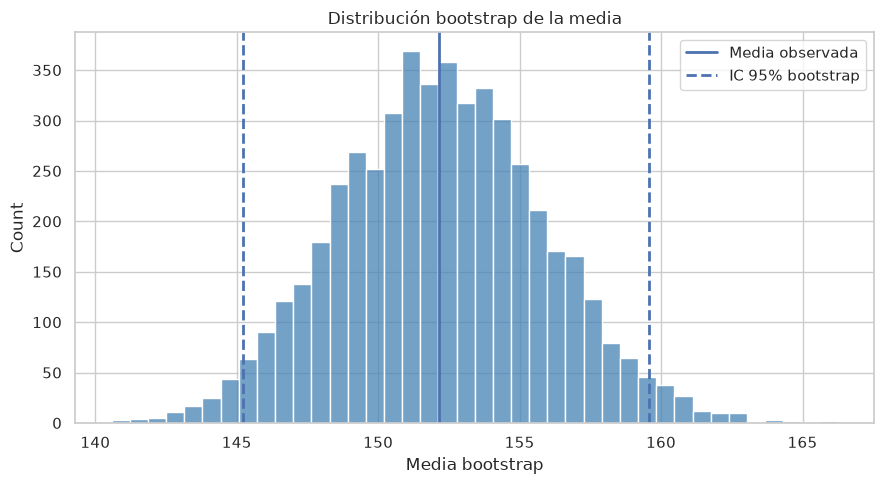

In [104]:
plt.figure(figsize=(9, 5))
sns.histplot(boot_means, bins=40, color="steelblue")
plt.axvline(diabetes["disease_progression"].mean(), linewidth=2, label="Media observada")
plt.axvline(ci_boot_mean[0], linestyle="--", linewidth=2, label="IC 95% bootstrap")
plt.axvline(ci_boot_mean[1], linestyle="--", linewidth=2)
plt.title("Distribución bootstrap de la media")
plt.xlabel("Media bootstrap")
plt.legend()
plt.tight_layout()
plt.show()

# 17. Bootstrap para una correlación

Pregunta:

> ¿Qué tan incierta es la correlación entre BMI y progresión de enfermedad?

Parámetro:

$$
\rho = Corr(X,Y).
$$

Estimador:

$$
r = \frac{\sum_{i=1}^{n}(x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum_{i=1}^{n}(x_i-\bar x)^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar y)^2}}.
$$

In [108]:
xy = diabetes[["bmi", "disease_progression"]].dropna().to_numpy()
rng = np.random.default_rng(321)
B = 5000
boot_corr = np.empty(B)

for b in range(B):
    idx = rng.choice(len(xy), size=len(xy), replace=True)
    muestra = xy[idx]
    boot_corr[b] = np.corrcoef(muestra[:, 0], muestra[:, 1])[0, 1]

corr_obs = np.corrcoef(xy[:, 0], xy[:, 1])[0, 1]
ci_corr = np.percentile(boot_corr, [2.5, 97.5])

print(f"Correlación observada: {corr_obs:.3f}")
print(f"IC bootstrap 95%: [{ci_corr[0]:.3f}, {ci_corr[1]:.3f}]")

Correlación observada: 0.586
IC bootstrap 95%: [0.521, 0.646]


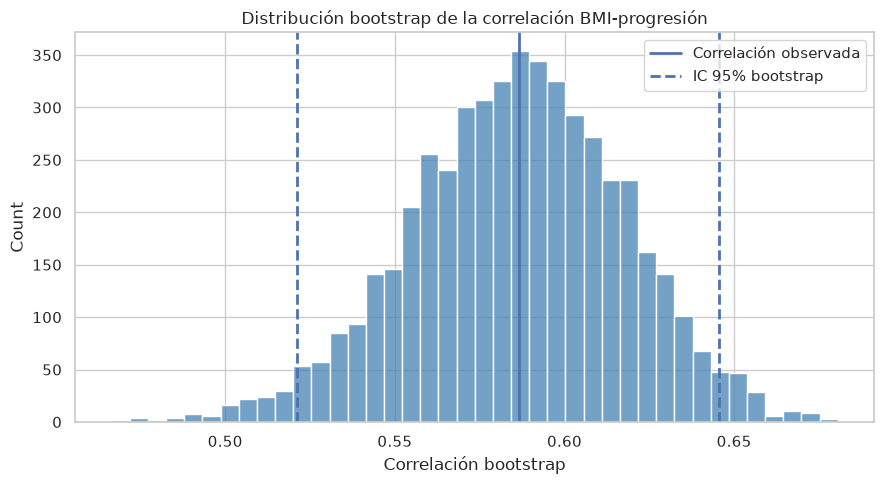

In [109]:
plt.figure(figsize=(9, 5))
sns.histplot(boot_corr, bins=40, color="steelblue")
plt.axvline(corr_obs, linewidth=2, label="Correlación observada")
plt.axvline(ci_corr[0], linestyle="--", linewidth=2, label="IC 95% bootstrap")
plt.axvline(ci_corr[1], linestyle="--", linewidth=2)
plt.title("Distribución bootstrap de la correlación BMI-progresión")
plt.xlabel("Correlación bootstrap")
plt.legend()
plt.tight_layout()
plt.show()

# 18. Interpretación de resultados 

Una interpretación completa debe incluir:

1. La pregunta respondida.
2. La variable analizada.
3. El método usado.
4. El resultado numérico.
5. La incertidumbre.
6. La decisión estadística si aplica.
7. La interpretación contextual.
8. Las limitaciones.

Ejemplo:

> En la base WDBC, el radio medio de los tumores malignos fue mayor que el de los tumores benignos. La diferencia estimada fue de aproximadamente X unidades y el intervalo de confianza del 95% no incluyó cero. Esto sugiere evidencia estadística de diferencia promedio entre diagnósticos. La conclusión es descriptiva-inferencial y no debe interpretarse como causalidad.

# 19. Errores frecuentes

## Error 1. Confundir muestra con población

La muestra observada no es automáticamente toda la población.

## Error 2. Interpretar mal el p-valor

El p-valor no es la probabilidad de que $H_0$ sea verdadera.

## Error 3. Confundir significancia estadística con importancia práctica

Una diferencia puede ser estadísticamente significativa y tener poca relevancia práctica.

## Error 4. Ignorar supuestos

Independencia, representatividad y tamaño muestral importan.

## Error 5. Reportar solo “rechazo/no rechazo”

Siempre debe reportarse el tamaño del efecto, el intervalo de confianza y el contexto.

## Error 6. Usar bootstrap como solución mágica

Bootstrap aproxima la variabilidad bajo la muestra observada, pero no corrige sesgos de selección.

# 21. Ejercicios (Quiz 1)

## Ejercicio 1. Intervalo de confianza para una media

Con la base de diabetes, construya un IC del 95% para la media de `bmi`. Interprete el resultado.

In [ ]:
# Escriba su solución aquí

## Ejercicio 2. Comparación entre grupos

Compare la progresión de enfermedad entre `BMI alto` y `BMI bajo`. Calcule diferencia de medias, IC y prueba t de Welch.

In [ ]:
# Escriba su solución aquí

## Ejercicio 3. Bootstrap para una mediana

Use bootstrap para construir un IC del 95% para la mediana de `disease_progression`.

In [ ]:
# Escriba su solución aquí

## Ejercicio 4. Proporción

En la base WDBC, estime la proporción de tumores benignos y construya un IC del 95%.

In [ ]:
# Escriba su solución aquí

## Ejercicio 5. Prueba de proporción

Pruebe si la proporción de tumores benignos difiere de 60%.

In [ ]:
# Escriba su solución aquí

## Ejercicio 6. Correlación

Calcule e interprete la correlación entre `mean area` y `mean radius` en la base WDBC. Luego use bootstrap para su IC.

In [ ]:
# Escriba su solución aquí

## Ejercicio 7. Interpretación

Redacte una conclusión completa para la comparación entre tumores malignos y benignos usando `mean texture`.

In [ ]:
# Escriba su solución aquí

## Ejercicio 8. Criterio 

Explique por qué un resultado estadísticamente significativo puede no ser importante en la práctica.

In [ ]:
# Escriba su solución aquí